# 🏎️ Exploratory Data Analysis
### Fifteen seasons of Formula 1 in the raw data (2010–2024)

Before any feature engineering, this notebook explores the **raw ingested data**
(`data/raw/*.csv`) to understand the sport and the sources that later become
`features.parquet`. Feature-engineering and modeling-readiness checks live in
`02_feature_analysis`; here we just ask: *what does this data look like?*

---

### TL;DR — what the exploration finds

| | |
|---|---|
| 🗓️ **Scope** | ~305 races over 2010–2024, ~20-car grids, 30+ circuits worldwide |
| 🧩 **Sources** | 9 raw tables: results, qualifying, standings, pit stops, tyres, weather |
| 👑 **Dominance** | a handful of eras where one team/driver wins most of the season |
| 🎯 **Grid matters** | pole converts to a win far above chance — grid is the key signal |
| 🔧 **Reliability** | DNF rates fall sharply from the early-2010s to today |
| 🌦️ **Coverage gaps** | lap-level weather & tyre data only exist from 2018 (FastF1 era) |

> **This notebook, in order:** ① the raw sources · ② the calendar · ③ the grid ·
> ④ championship dominance · ⑤ qualifying → race · ⑥ reliability & attrition ·
> ⑦ pit stops & tyres · ⑧ weather coverage.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "data" / "raw" / "results.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RAW = ROOT / "data" / "raw"

# --- one shared visual theme, applied to every chart below ---
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "figure.facecolor": "white",
    "axes.facecolor": "white", "font.size": 11, "axes.titlesize": 13,
    "axes.titleweight": "bold", "axes.labelsize": 11, "axes.edgecolor": "#c8ccd0",
    "axes.grid": True, "grid.color": "#e9ebec", "grid.linewidth": 0.9,
    "axes.axisbelow": True, "legend.frameon": False,
    "xtick.color": "#4a4f55", "ytick.color": "#4a4f55", "axes.labelcolor": "#2b2f36",
})
C = {"baseline": "#9aa0a6", "rf": "#6b8fd4", "xgb": "#4c6ef5", "lgbm": "#12b886",
     "stack": "#e8590c", "good": "#2f9e44", "bad": "#e03131", "ink": "#2b2f36",
     "violet": "#7048e8"}

def despine(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

# Load the raw tables, and clip everything to the seasons that actually have
# results (races.csv also holds future 2025/26 rounds for live inference).
results = pd.read_csv(RAW / "results.csv")
races = pd.read_csv(RAW / "races.csv")
qualifying = pd.read_csv(RAW / "qualifying.csv")
pit_stops = pd.read_csv(RAW / "pit_stops.csv")
weather = pd.read_csv(RAW / "race_weather.csv")
tyres = pd.read_csv(RAW / "tire_stints.csv")
N_RESULTS_RAW = len(results)  # true file size (before clipping)

# Clip to the modeling scope (features.parquet is 2010–2024); races.csv and
# results.csv also carry partial 2025/26 rows ingested for live inference.
results = results[results["season"].between(2010, 2024)].copy()
SMIN, SMAX = int(results["season"].min()), int(results["season"].max())
races_r = races[races["season"].between(SMIN, SMAX)].copy()
res = results.merge(races_r[["season", "round", "country", "circuit_id", "race_date"]],
                    on=["season", "round"], how="left")
res["status"] = res["status"].fillna("Unknown")
res["classified"] = res["status"].eq("Finished") | res["status"].str.startswith("+")
res["dnf"] = ~res["classified"]

print(f"Seasons {SMIN}–{SMAX}  |  results rows: {len(res)}  |  races: "
      f"{res[['season','round']].drop_duplicates().shape[0]}")
res.head(3)

Seasons 2010–2024  |  results rows: 6432  |  races: 305


,season,round,driver_id,driver_code,constructor_id,number,grid,finish_position,position_text,points,laps_completed,status,finish_time_ms,fastest_lap_rank,fastest_lap_time,country,circuit_id,race_date,classified,dnf
0,2024,1,max_verstappen,VER,red_bull,1,1,1.0,1,26.0,57,Finished,5504742.0,1.0,1:32.608,Bahrain,bahrain,2024-03-02,True,False
1,2024,1,perez,PER,red_bull,11,5,2.0,2,18.0,57,Finished,5527199.0,4.0,1:34.364,Bahrain,bahrain,2024-03-02,True,False
2,2024,1,sainz,SAI,ferrari,55,4,3.0,3,15.0,57,Finished,5529852.0,6.0,1:34.507,Bahrain,bahrain,2024-03-02,True,False


## 1 · The raw data sources

Nine ingested tables feed the pipeline. Each is a tidy, long-format CSV keyed by
`(season, round, …)`. This is the raw material `src.features.build_features`
turns into one model-ready row per driver per race.

In [2]:
inv = pd.DataFrame([
    ("results.csv",               N_RESULTS_RAW,  "season, round, driver",   "finishing position, grid, points, status, laps"),
    ("qualifying.csv",            len(qualifying),"season, round, driver",   "Q1/Q2/Q3 times, grid position"),
    ("driver_standings.csv",      len(pd.read_csv(RAW/'driver_standings.csv')),      "season, round, driver",      "championship position, points, wins"),
    ("constructor_standings.csv", len(pd.read_csv(RAW/'constructor_standings.csv')), "season, round, constructor", "constructor standings"),
    ("races.csv",                 len(races),     "season, round",           "circuit, locality, country, date, lat/lon"),
    ("pit_stops.csv",             len(pit_stops), "season, round, driver",   "stop lap & duration (seconds)"),
    ("tire_stints.csv",           len(tyres),     "season, round, driver",   "compound, stint laps (2018+)"),
    ("race_weather.csv",          len(weather),   "season, round",           "air/track temp, humidity, wind, rain (2018+)"),
], columns=["file", "rows", "grain", "holds"])
display(inv.style
        .format({"rows": "{:,d}"})
        .background_gradient(subset=["rows"], cmap="Blues")
        .set_caption("Raw data source inventory")
        .set_properties(subset=["holds"], **{"text-align": "left"})
        .hide(axis="index"))

file,rows,grain,holds
results.csv,"7,109","season, round, driver","finishing position, grid, points, status, laps"
qualifying.csv,"7,086","season, round, driver","Q1/Q2/Q3 times, grid position"
driver_standings.csv,"7,073","season, round, driver","championship position, points, wins"
constructor_standings.csv,"3,392","season, round, constructor",constructor standings
races.csv,351,"season, round","circuit, locality, country, date, lat/lon"
pit_stops.csv,"12,553","season, round, driver",stop lap & duration (seconds)
tire_stints.csv,"9,548","season, round, driver","compound, stint laps (2018+)"
race_weather.csv,178,"season, round","air/track temp, humidity, wind, rain (2018+)"


## 2 · The calendar — how the season grew

Races per season and the spread of host countries. The calendar expands markedly
over the era, which matters for any time-aware split.

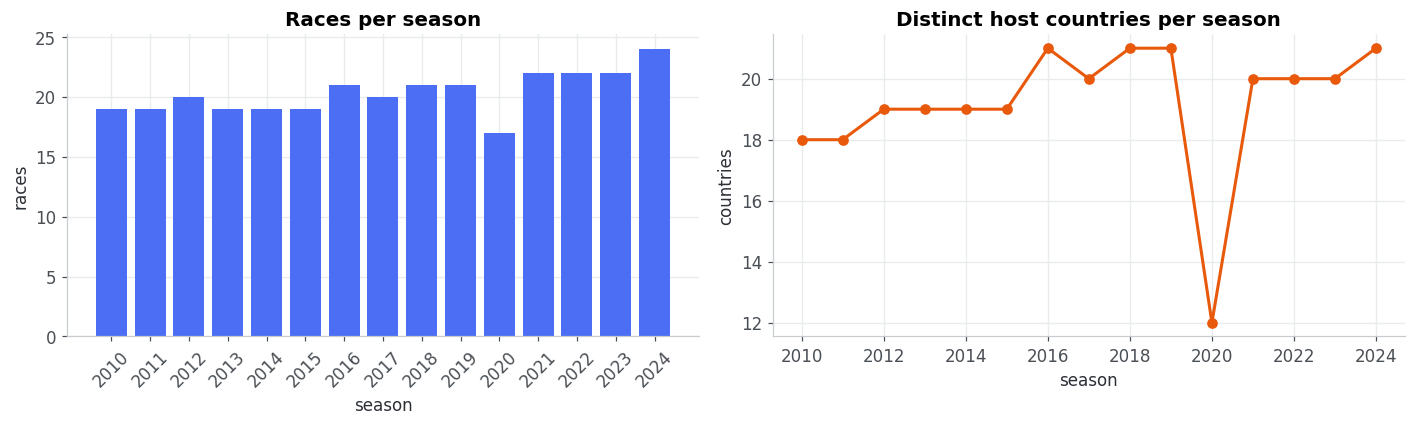

Most-visited countries (races hosted, 2010–2024):
country
Italy      20
Spain      18
USA        17
UK         16
Bahrain    15
Hungary    15
Belgium    15
UAE        15
Monaco     14
Brazil     14


In [3]:
per_season = res.groupby("season")["round"].nunique()
countries = res.groupby("season")["country"].nunique()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(per_season.index.astype(str), per_season.values, color=C["xgb"])
ax[0].set(title="Races per season", xlabel="season", ylabel="races")
ax[0].tick_params(axis="x", rotation=45); despine(ax[0])

ax[1].plot(countries.index, countries.values, "-o", color=C["stack"], lw=2)
ax[1].set(title="Distinct host countries per season", xlabel="season", ylabel="countries")
despine(ax[1])
plt.tight_layout(); plt.show()

top_countries = res.drop_duplicates(["season", "round"])["country"].value_counts().head(10)
print("Most-visited countries (races hosted, 2010–2024):")
print(top_countries.to_string())

## 3 · The grid — drivers & constructors over time

How many distinct drivers and constructors appear each season. Grid size is
stable (~20 cars) but the cast turns over.

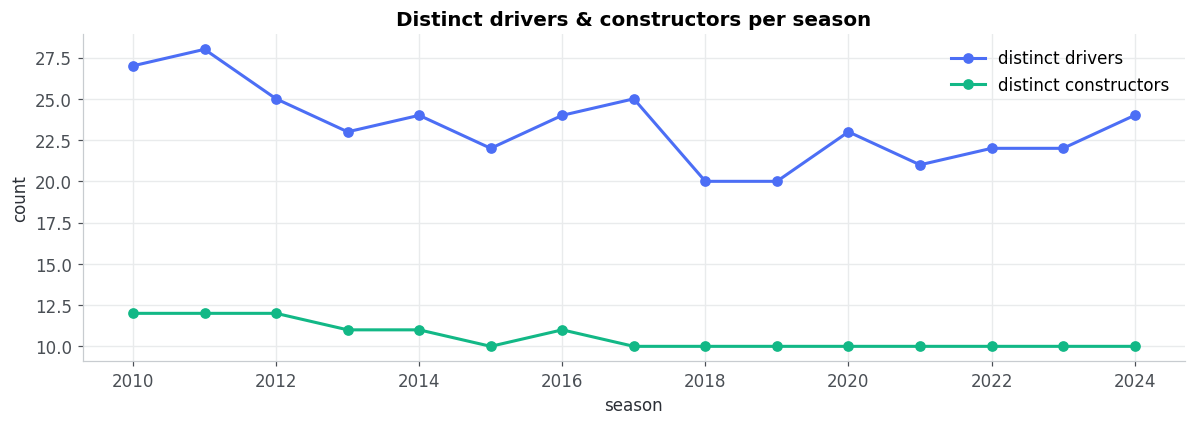

Total unique drivers 2010–2024: 80
Total unique constructors     : 23


In [4]:
drivers = res.groupby("season")["driver_id"].nunique()
teams = res.groupby("season")["constructor_id"].nunique()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(drivers.index, drivers.values, "-o", color=C["xgb"], lw=2, label="distinct drivers")
ax.plot(teams.index, teams.values, "-o", color=C["lgbm"], lw=2, label="distinct constructors")
ax.set(title="Distinct drivers & constructors per season", xlabel="season", ylabel="count")
ax.legend(); despine(ax)
plt.tight_layout(); plt.show()

print(f"Total unique drivers 2010–2024: {res['driver_id'].nunique()}")
print(f"Total unique constructors     : {res['constructor_id'].nunique()}")

## 4 · Championship dominance — how one-sided was each season?

For each season, the share of race wins taken by the single most successful
driver and constructor. Peaks are the dynasty years (one team winning almost
everything); dips are the competitive seasons.

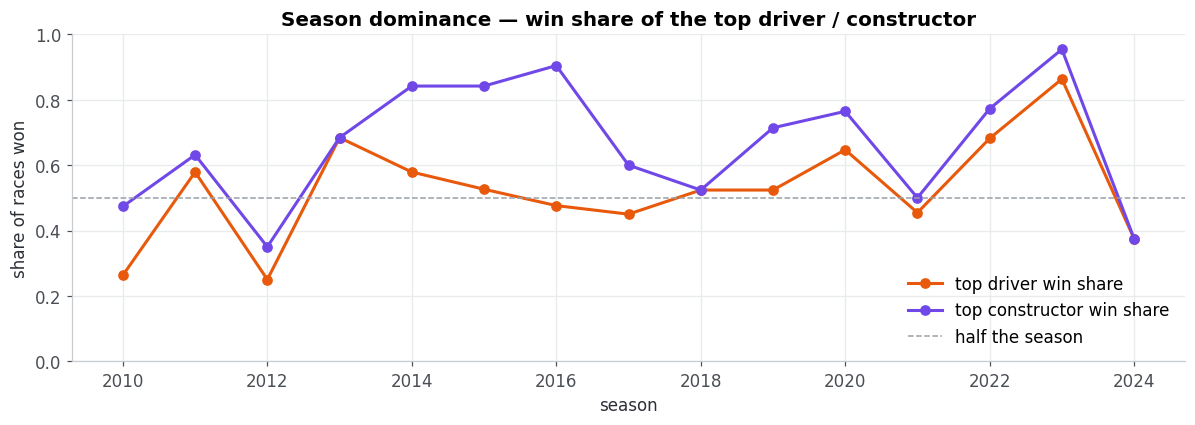

Most race wins in the dataset (2010–2024):
driver_id
hamilton          94
max_verstappen    63
vettel            48
rosberg           23
alonso            11
bottas            10
ricciardo          8
button             8


In [5]:
races_ps = res.groupby("season")["round"].nunique()
winners = res[res["finish_position"] == 1]
drv_top = winners.groupby(["season", "driver_id"]).size().groupby("season").max() / races_ps
con_top = winners.groupby(["season", "constructor_id"]).size().groupby("season").max() / races_ps

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(drv_top.index, drv_top.values, "-o", color=C["stack"], lw=2, label="top driver win share")
ax.plot(con_top.index, con_top.values, "-o", color=C["violet"], lw=2, label="top constructor win share")
ax.axhline(0.5, color=C["baseline"], ls="--", lw=1, label="half the season")
ax.set(title="Season dominance — win share of the top driver / constructor",
       xlabel="season", ylabel="share of races won"); ax.set_ylim(0, 1)
ax.legend(); despine(ax)
plt.tight_layout(); plt.show()

top_all = winners["driver_id"].value_counts().head(8)
print("Most race wins in the dataset (2010–2024):")
print(top_all.to_string())

## 5 · Qualifying → race — does starting position decide the result?

The relationship the whole project hinges on. Left: how often pole position
converts to a win (far above the ~5% you'd get by chance). Right: grid vs finish
— a strong diagonal, and the reason "finish = grid" is such a stubborn baseline.

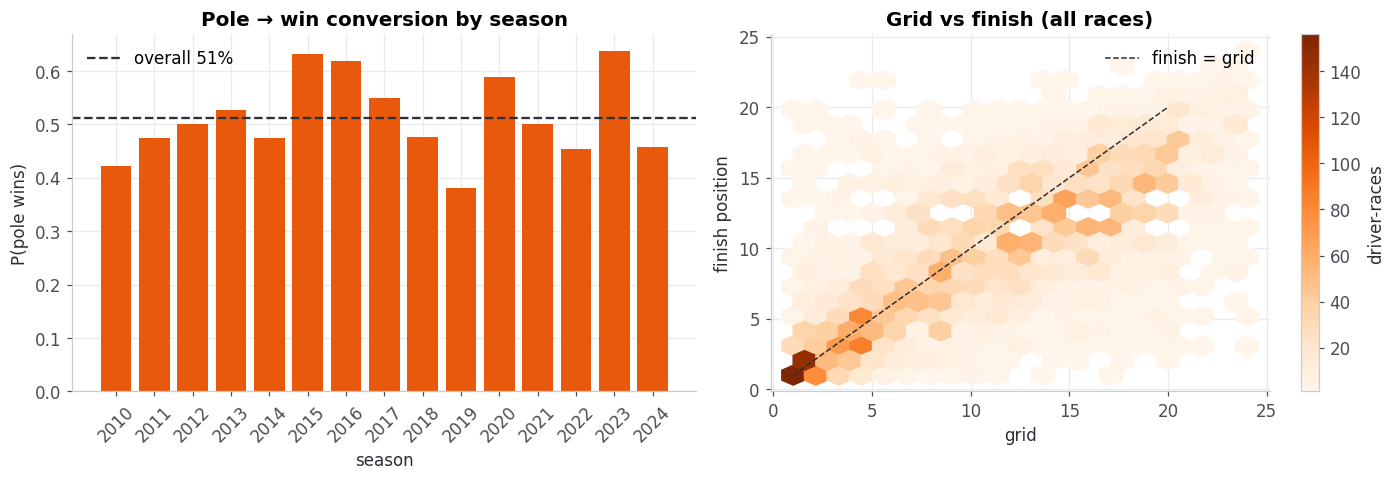

Spearman(grid, finish) = 0.762  |  pole-to-win rate = 51.1%


In [6]:
pole = res[res["grid"] == 1][["season", "round", "driver_id"]]
win = res[res["finish_position"] == 1][["season", "round", "driver_id"]]
pw = pole.merge(win, on=["season", "round"], suffixes=("_pole", "_win"))
pw["pole_won"] = pw["driver_id_pole"] == pw["driver_id_win"]
conv = pw.groupby("season")["pole_won"].mean()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(conv.index.astype(str), conv.values, color=C["stack"])
ax[0].axhline(pw["pole_won"].mean(), color=C["ink"], ls="--",
              label=f"overall {pw['pole_won'].mean():.0%}")
ax[0].set(title="Pole → win conversion by season", xlabel="season", ylabel="P(pole wins)")
ax[0].tick_params(axis="x", rotation=45); ax[0].legend(); despine(ax[0])

sub = res.dropna(subset=["finish_position"])
sub = sub[(sub["grid"] >= 1) & (sub["finish_position"] >= 1)]
hb = ax[1].hexbin(sub["grid"], sub["finish_position"], gridsize=20, cmap="Oranges", mincnt=1)
ax[1].plot([1, 20], [1, 20], "--", color=C["ink"], lw=1, label="finish = grid")
ax[1].set(title="Grid vs finish (all races)", xlabel="grid", ylabel="finish position")
ax[1].legend(); despine(ax[1]); fig.colorbar(hb, ax=ax[1], label="driver-races")
plt.tight_layout(); plt.show()

corr = sub["grid"].corr(sub["finish_position"], method="spearman")
print(f"Spearman(grid, finish) = {corr:.3f}  |  pole-to-win rate = {pw['pole_won'].mean():.1%}")

## 6 · Reliability & attrition — the cars finish more often now

Share of entries that fail to be classified (mechanical failures, crashes). The
early-2010s attrition is far higher than today — the reason the grid baseline is
noisier in early seasons.

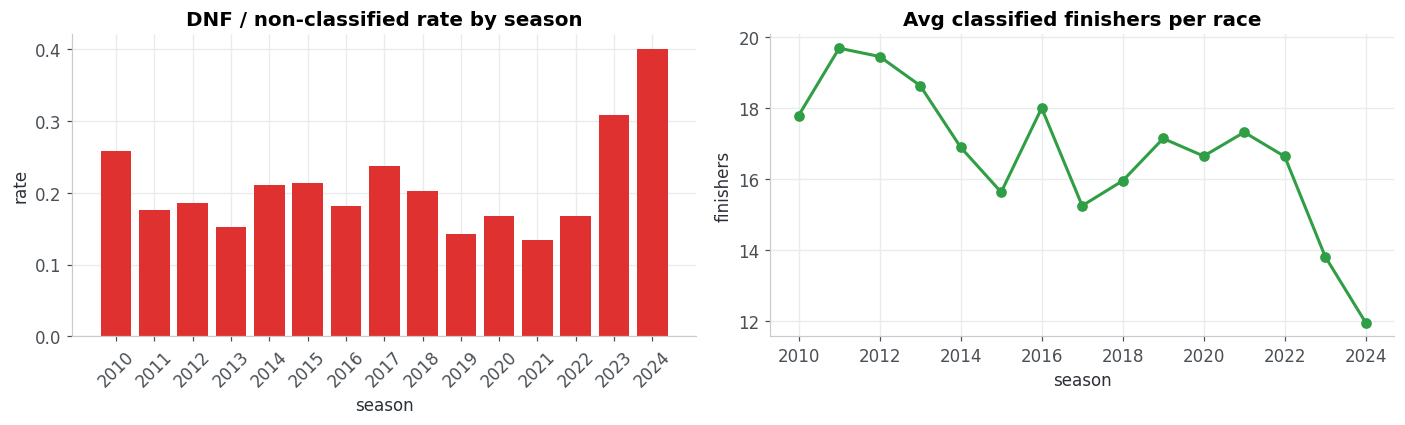

Top retirement reasons (status, excluding classified):
status
Collision           215
Lapped              208
Retired             157
Accident            122
Engine               90
Gearbox              63
Brakes               53
Collision damage     47


In [7]:
dnf_rate = res.groupby("season")["dnf"].mean()
finishers = res[res["classified"]].groupby(["season", "round"]).size().groupby("season").mean()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(dnf_rate.index.astype(str), dnf_rate.values, color=C["bad"])
ax[0].set(title="DNF / non-classified rate by season", xlabel="season", ylabel="rate")
ax[0].tick_params(axis="x", rotation=45); despine(ax[0])

ax[1].plot(finishers.index, finishers.values, "-o", color=C["good"], lw=2)
ax[1].set(title="Avg classified finishers per race", xlabel="season", ylabel="finishers")
despine(ax[1])
plt.tight_layout(); plt.show()

print("Top retirement reasons (status, excluding classified):")
print(res[res["dnf"]]["status"].value_counts().head(8).to_string())

## 7 · The pit lane & tyres

Pit-stop service times (a clean ~2–3s modern stop, with a long tail of slow /
penalty stops) and tyre-compound usage. Tyre-stint data begins in 2018 (FastF1).

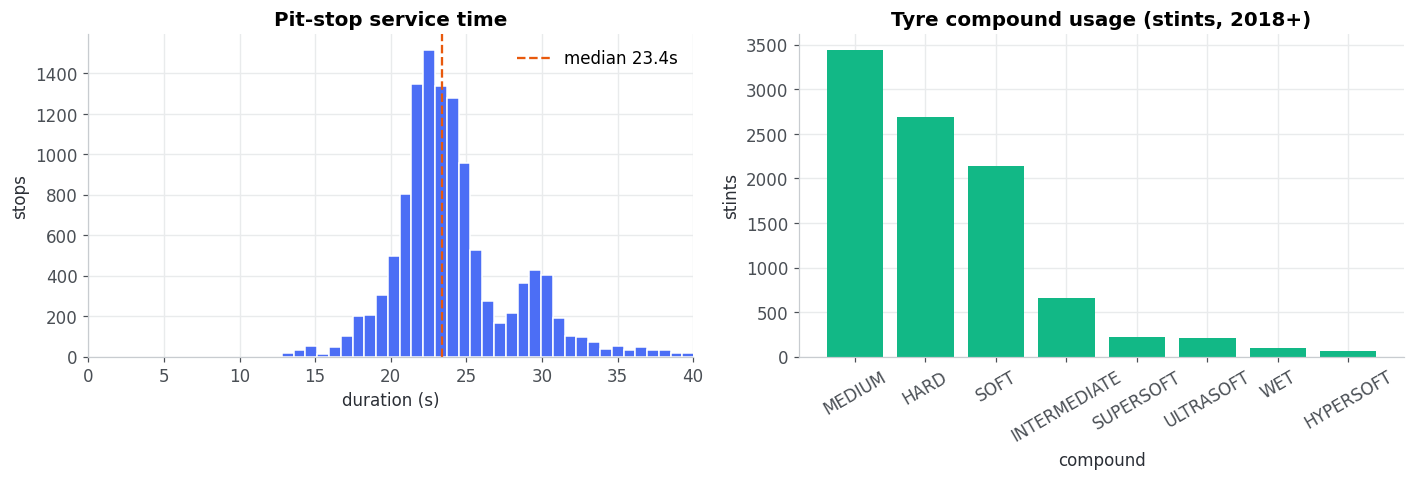

Avg pit stops per driver per race (first & last available seasons):
season
2011    2.596737
2012    2.116331
2013    2.371571
...
season
2024    1.805252
2025    1.800439
2026    2.022346


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
dur = pit_stops["duration_seconds"]
clean = dur[(dur > 1) & (dur < 60)]
ax[0].hist(clean, bins=60, color=C["xgb"], edgecolor="white")
ax[0].axvline(clean.median(), color=C["stack"], ls="--", label=f"median {clean.median():.1f}s")
ax[0].set(title="Pit-stop service time", xlabel="duration (s)", ylabel="stops")
ax[0].set_xlim(0, 40); ax[0].legend(); despine(ax[0])

comp = tyres["compound"].value_counts().head(8)
ax[1].bar(comp.index, comp.values, color=C["lgbm"])
ax[1].set(title="Tyre compound usage (stints, 2018+)", xlabel="compound", ylabel="stints")
ax[1].tick_params(axis="x", rotation=30); despine(ax[1])
plt.tight_layout(); plt.show()

stops_pr = (pit_stops.groupby(["season", "round", "driver_id"]).size()
            .groupby("season").mean())
print("Avg pit stops per driver per race (first & last available seasons):")
print(stops_pr.head(3).to_string()); print("..."); print(stops_pr.tail(3).to_string())

## 8 · Weather coverage — a 2018 cliff

Lap-level weather comes from FastF1, which only covers **2018 onward**. This is
why the feature pipeline carries an explicit `weather_missing` flag rather than
silently imputing pre-2018 races.

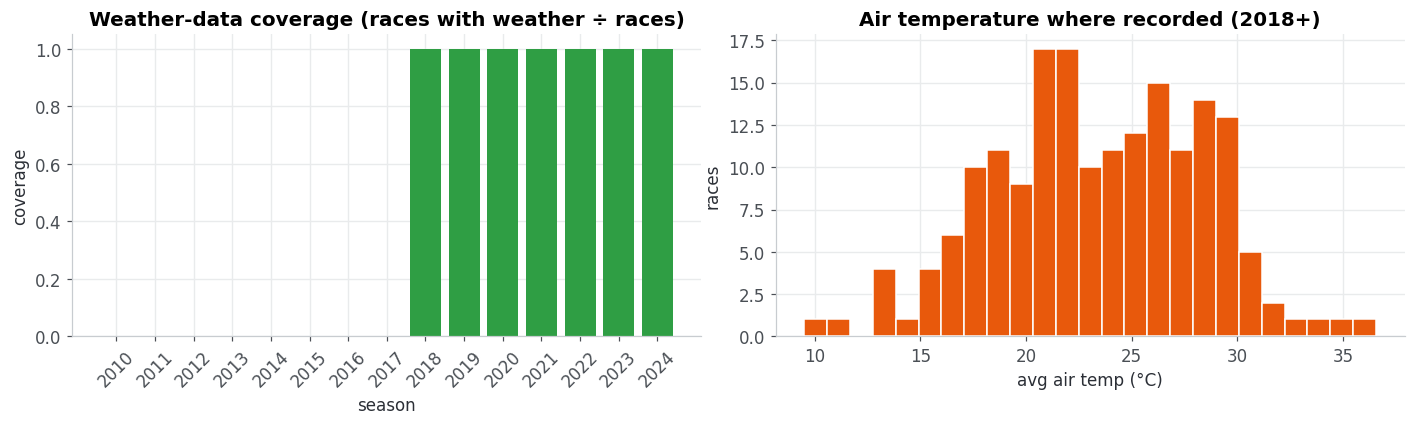

Races with recorded weather: 178  |  of those, wet (rainfall>0): 45


In [9]:
wx = weather.merge(races_r[["season", "round"]], on=["season", "round"], how="inner")
cover = (wx.groupby("season").size() / res.groupby("season")["round"].nunique()).reindex(
    range(SMIN, SMAX + 1)).fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(cover.index.astype(str), cover.values,
          color=[C["good"] if v > 0 else C["baseline"] for v in cover.values])
ax[0].set(title="Weather-data coverage (races with weather ÷ races)",
          xlabel="season", ylabel="coverage")
ax[0].tick_params(axis="x", rotation=45); despine(ax[0])

ax[1].hist(weather["air_temp_avg"].dropna(), bins=25, color=C["stack"], edgecolor="white")
ax[1].set(title="Air temperature where recorded (2018+)", xlabel="avg air temp (°C)", ylabel="races")
despine(ax[1])
plt.tight_layout(); plt.show()

wet = (weather["rainfall"] > 0).sum()
print(f"Races with recorded weather: {len(weather)}  |  of those, wet (rainfall>0): {wet}")

## 9 · Takeaways → onward to feature engineering

- **Grid position is the dominant signal** — a strong grid↔finish diagonal and a
  well-above-chance pole-to-win rate. Any model must beat "finish = grid".
- **The era matters** — calendar growth, driver/team turnover, and *falling DNF
  rates* mean early and recent seasons behave differently; a **time-aware split**
  is essential (used in 02/03/04).
- **Coverage is uneven by design** — lap-level weather and tyre data only exist
  from 2018, so those features must be explicitly flagged, not imputed.
- **Dominance comes in waves** — some seasons are near-monopolies, others tight;
  ratings features (dual-ELO in 02) need to track this.

Next: **`02_feature_analysis`** — how these raw tables become one leakage-free,
model-ready row per driver per race.